# Exploratory data analysis

What the two datasets look like before any model is trained:

- **MusicCaps**: 10-second YouTube clips with musician-written captions and aspect tags (stages 1, 3 and 4)
- **FMA-small**: 30-second tracks from 8 genres (stage 2)

It also measures how much MusicCaps captions leak their own labels, and shows how a clip becomes a graph.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

from src.audio_features import extract_features, load_audio, segment_bounds
from src.datasets import load_fma_small, load_musiccaps, mask_tags, tag_mask_pattern
from src.plots import BLUE, INK_SECONDARY, SERIES, style
from src.tags import phrases_for
from src.utils import load_config, resolve

style()
cfg = load_config()
caps = load_musiccaps(cfg)
fma = load_fma_small(cfg)

## MusicCaps: size, splits and audio availability

Test = AudioSet evaluation clips; 10% of the rest go to validation by a hash of the video id. Some YouTube videos are private or removed, so not every caption has audio.

In [2]:
summary = caps.groupby('split').agg(captions=('ytid', 'size'), with_audio=('has_audio', 'sum')).loc[['train', 'val', 'test']]
summary.loc['total'] = summary.sum()
summary['audio_share'] = (summary['with_audio'] / summary['captions']).round(3)
summary

,captions,with_audio,audio_share
split,,,
train,2406,2121,0.882
val,257,234,0.911
test,2858,2555,0.894
total,5521,4910,0.889


## Aspect lists are noisy, so synonyms are merged

The same idea is written many ways. `src/tags.py` merges rewordings into canonical tags, and the 50 most frequent canonical tags on the training split become the labels.

In [3]:
raw_counts = Counter(a for aspects in caps['aspects'] for a in aspects)
tag_counts = Counter(t for tags in caps['tags'] for t in tags)
print(f'{len(raw_counts):,} distinct raw aspects, {len(tag_counts):,} after merging synonyms')

vocab_counts = json.loads((resolve(cfg['paths']['splits']) / 'musiccaps_tags.json').read_text(encoding='utf-8'))
vocab = list(vocab_counts)
for tag in ['male vocals', 'low quality', 'bass', 'relaxing']:
    merged = {p: raw_counts[p] for p in phrases_for(tag) if raw_counts[p]}
    print(f'\n{tag}: {tag_counts[tag]} clips, merged from {merged}')

13,219 distinct raw aspects, 13,093 after merging synonyms

male vocals: 1123 clips, merged from {'male vocals': 48, 'male voice': 224, 'male vocal': 208, 'male singer': 195, 'male vocalist': 109, 'male voice singing': 96, 'flat male vocal': 151, 'passionate male vocal': 96}

low quality: 1674 clips, merged from {'low quality': 1220, 'poor audio quality': 236, 'bad audio quality': 85, 'low quality audio': 74, 'low quality recording': 52, 'inferior audio quality': 39}

bass: 1241 clips, merged from {'bass': 178, 'bass guitar': 297, 'e-bass': 222, 'groovy bass': 229, 'groovy bass line': 127, 'groovy bass guitar': 61, 'smooth bass': 46, 'strong bass line': 41, 'percussive bass line': 47}

relaxing: 370 clips, merged from {'relaxing': 146, 'calming': 142, 'soothing': 111, 'calm': 41, 'chill': 47, 'meditative': 53}


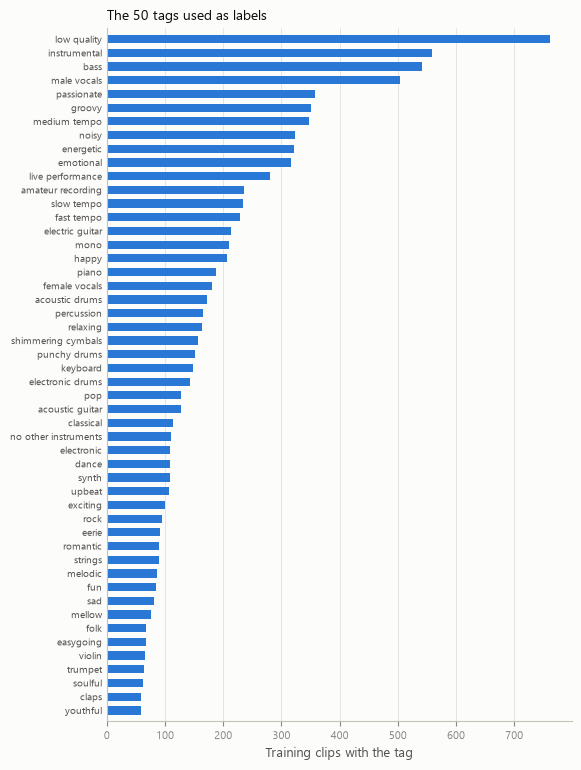

In [4]:
names, counts = list(vocab_counts)[::-1], list(vocab_counts.values())[::-1]
fig, ax = plt.subplots(figsize=(6, 9))
ax.barh(names, counts, height=0.6, color=SERIES[0])
ax.set_xlabel('Training clips with the tag')
ax.grid(axis='y', visible=False)
ax.tick_params(axis='y', length=0, labelsize=7, labelcolor=INK_SECONDARY)
ax.margins(y=0.01)
ax.set_title('The 50 tags used as labels', loc='left')
plt.show()

## Captions: length and label leakage

Each caption was written together with its aspect list, so many labels are spelled out in the text. Stage 1 is therefore run twice: on raw captions and with tag phrases replaced by `[MASK]`.

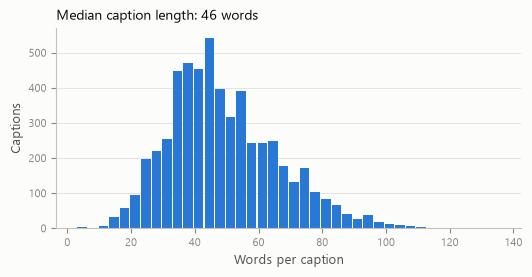

In [5]:
words = caps['caption'].str.split().str.len()
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.hist(words, bins=40, color=SERIES[0], rwidth=0.9)
ax.set_xlabel('Words per caption')
ax.set_ylabel('Captions')
ax.grid(axis='x', visible=False)
ax.set_title(f'Median caption length: {words.median():.0f} words', loc='left')
plt.show()

In [6]:
top_raw = {a for a, _ in raw_counts.most_common(50)}
positives = verbatim = 0
for caption, aspects in zip(caps['caption'].str.lower(), caps['aspects']):
    for aspect in set(aspects) & top_raw:
        positives += 1
        verbatim += aspect in caption
print(f'{verbatim / positives:.1%} of positive (clip, aspect) pairs for the 50 most common raw aspects appear verbatim in the caption')

pattern = tag_mask_pattern(vocab)
masked = caps['caption'].map(lambda c: mask_tags(c, pattern))
print(f'Masking tag phrases hides {(masked.str.count(r"\[MASK\]") / words).mean():.1%} of caption words on average\n')
print('RAW:   ', caps['caption'][0])
print('MASKED:', masked[0])

65.6% of positive (clip, aspect) pairs for the 50 most common raw aspects appear verbatim in the caption


Masking tag phrases hides 10.4% of caption words on average

RAW:    The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
MASKED: The [MASK] features a ballad song that contains sustained [MASK], [MASK] [MASK] melody and [MASK] [MASK] singing over it. It sounds [MASK] and [MASK], like something you would hear at Sunday services.


## FMA-small: genres and the artist-filtered split

In [7]:
pd.crosstab(fma['genre'], fma['split'])[['train', 'val', 'test']]

split,train,val,test
genre,,,
Electronic,800,100,100
Experimental,800,100,100
Folk,800,100,100
Hip-Hop,800,100,100
Instrumental,800,100,100
International,800,100,100
Pop,800,100,100
Rock,800,100,100


In [8]:
artists = {split: set(fma.loc[fma['split'] == split, 'artist_id']) for split in ('train', 'val', 'test')}
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    print(f'artists in both {a} and {b}: {len(artists[a] & artists[b])}')

artists in both train and val: 0
artists in both train and test: 0
artists in both val and test: 0


## From audio to a graph

Audio is resampled to 22,050 Hz and turned into a log-mel spectrogram, chroma and MFCCs. Overlapping 1 s windows every 0.5 s become the graph's nodes (white lines mark every other window).

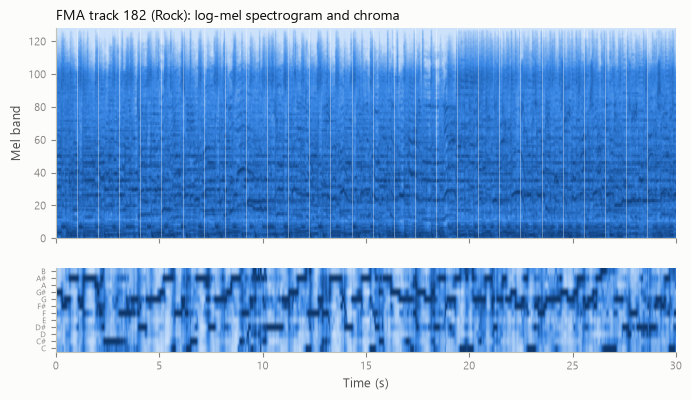

57 segments of 1.0 s every 0.5 s


In [9]:
track = fma[fma['split'] == 'test'].iloc[0]
y = load_audio(track['audio_path'], cfg['audio']['sample_rate'], max_seconds=30)
features = extract_features(y, cfg['audio'])
bounds = segment_bounds(features, cfg['segments'])
seconds = features.n_frames / features.frame_rate

fig, axes = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]})
axes[0].imshow(features.log_mel, origin='lower', aspect='auto', extent=[0, seconds, 0, features.log_mel.shape[0]], cmap=BLUE)
axes[0].set_ylabel('Mel band')
axes[0].set_title(f"FMA track {track['track_id']} ({track['genre']}): log-mel spectrogram and chroma", loc='left')
for start in bounds[::2, 0] / features.frame_rate:
    axes[0].axvline(start, color='white', linewidth=0.4, alpha=0.6)
axes[1].imshow(features.chroma, origin='lower', aspect='auto', extent=[0, seconds, 0, 12], cmap=BLUE)
axes[1].set_yticks(np.arange(12) + 0.5, ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'], fontsize=6)
axes[1].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(False)
plt.show()
print(f"{len(bounds)} segments of {cfg['segments']['window_seconds']} s every {cfg['segments']['hop_seconds']} s")

In [10]:
root = resolve(cfg['paths']['processed']) / 'fma_small'
segment_graphs = torch.load(root / 'segment_graphs.pt', weights_only=False)
chord_graphs = torch.load(root / 'chord_graphs.pt', weights_only=False)

def describe(graphs):
    nodes = np.array([g.num_nodes for g in graphs.values()])
    edges = np.array([g.num_edges for g in graphs.values()])
    return pd.Series({'graphs': len(graphs), 'median nodes': np.median(nodes), 'median edges': np.median(edges), 'max edges': edges.max()})

similar_share = np.mean([float(g.edge_attr[:, 1].mean()) for g in segment_graphs.values()])
print(f'Similarity edges are {similar_share:.0%} of segment-graph edges on average; the rest link neighbours in time')
pd.DataFrame({'segment graphs': describe(segment_graphs), 'chord graphs': describe(chord_graphs)})

Similarity edges are 58% of segment-graph edges on average; the rest link neighbours in time


,segment graphs,chord graphs
graphs,7994.0,7994.0
median nodes,57.0,8.0
median edges,294.0,17.0
max edges,822.0,51.0


In [11]:
g = chord_graphs[int(track['track_id'])]
src, dst = g.edge_index.tolist()
transitions = sorted(zip(src, dst, g.edge_attr[:, 0].tolist()), key=lambda t: -t[2])
print('chords in this track:', g.chords)
print('most frequent transitions:', [(g.chords[s], g.chords[d], int(n)) for s, d, n in transitions[:6]])

chords in this track: ['F:min', 'G:min', 'D#:maj', 'N', 'A#:maj', 'C#:maj', 'A#:min', 'F#:maj', 'F:maj', 'D#:min', 'C:min']
most frequent transitions: [('D#:maj', 'N', 9), ('N', 'D#:maj', 8), ('G:min', 'D#:maj', 3), ('N', 'C:min', 3), ('A#:min', 'N', 3), ('G:min', 'N', 2)]


The arc diagram below draws a whole segment graph: arcs join moments of a track that sound alike. `python -m src.plots` regenerates it.

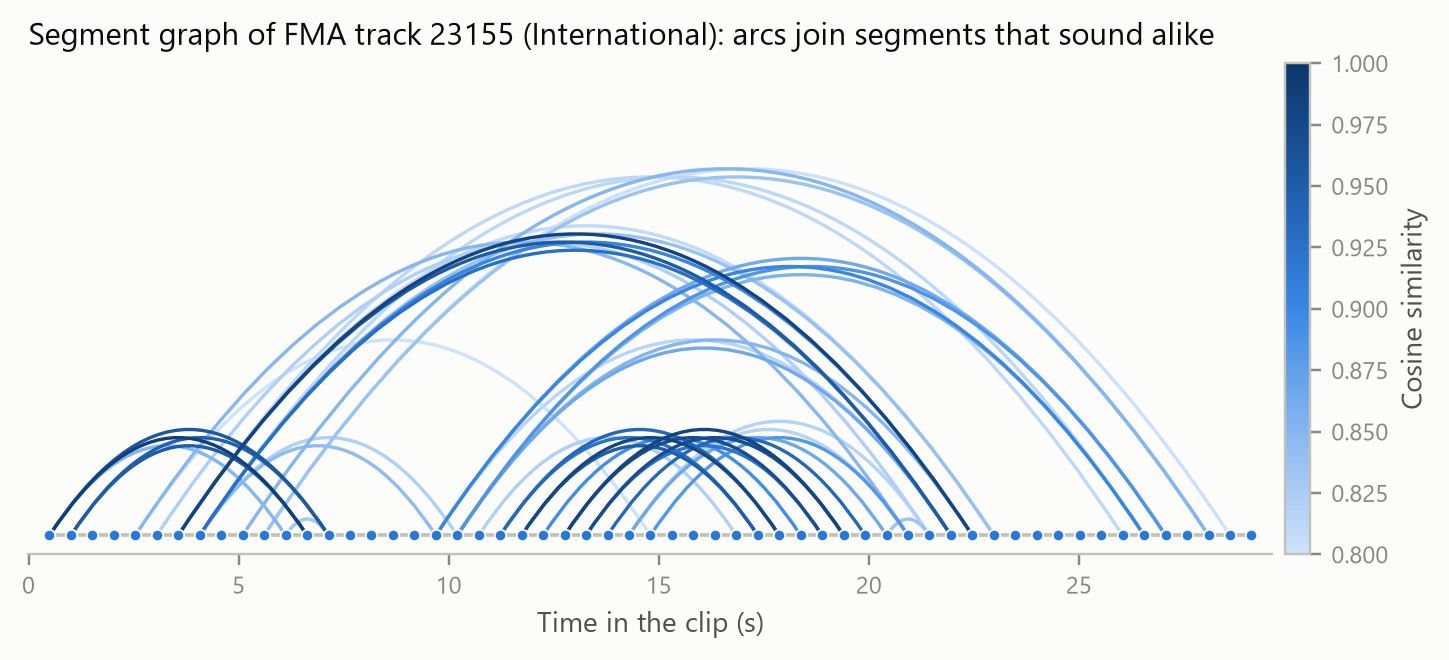

In [12]:
arc = resolve('results/plots/song_arc_diagram.png')
display(Image(filename=str(arc))) if arc.exists() else print('Run `python -m src.plots` first')